In [6]:
import time
import pandas as pd
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service as ChromeService
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

# --- 1. Поставување на Selenium WebDriver ---
options = Options()
options.add_argument("--headless")  # Работи во позадина
options.add_argument("--no-sandbox")
options.add_argument("--disable-dev-shm-usage")
service = ChromeService(ChromeDriverManager().install())
driver = webdriver.Chrome(service=service, options=options)

# Поставување на "explicit wait". Ќе чекаме максимум 10 секунди
wait = WebDriverWait(driver, 10)

url = "https://www.scrapethissite.com/pages/ajax-javascript/"
all_movies_data = []

print("Selenium WebDriver е стартуван...")

try:
    driver.get(url)
    
    # --- 2. Наоѓање на сите линкови за годините ---
    # Прво ги читаме сите години во листа
    year_link_elements = driver.find_elements(By.CSS_SELECTOR, "a.year-link")
    # Ги зачувуваме како текст, бидејќи елементите може да станат "stale"
    years_to_scrape = [elem.text for elem in year_link_elements]
    
    print(f"Пронајдени години за обработка: {years_to_scrape}")

    # --- 3. Итерација низ секоја година ---
    for year in years_to_scrape:
        print(f"Обработувам година: {year}...")
        
        # Го наоѓаме линкот повторно (за да избегнеме StaleElementReferenceException)
        year_link = driver.find_element(By.LINK_TEXT, year)
        year_link.click()
        
        # --- 4. КЛУЧЕН ЧЕКОР: Чекаме AJAX да заврши ---
        # Чекаме додека 'div#loading' (со иконата за вчитување)
        # не стане невидлив (display: none).
        wait.until(EC.invisibility_of_element_located((By.ID, "loading")))
        
        # --- 5. Собирање на податоците за филмовите ---
        movie_rows = driver.find_elements(By.CSS_SELECTOR, "tr.film")
        print(f"  Пронајдени {len(movie_rows)} филмови.")
        
        for row in movie_rows:
            try:
                title = row.find_element(By.CSS_SELECTOR, "td.film-title").text
                nominations = row.find_element(By.CSS_SELECTOR, "td.film-nominations").text
                awards = row.find_element(By.CSS_SELECTOR, "td.film-awards").text
                
                all_movies_data.append({
                    'title': title,
                    'nominations': int(nominations),
                    'awards': int(awards),
                    'year': int(year) # Ја додаваме годината што ја кликнавме
                })
            except Exception as e:
                print(f"  Грешка при парсирање на ред: {e}")

finally:
    # --- 6. Затворање на прелистувачот ---
    driver.quit()
    print("WebDriver е затворен.")

# --- 7. Креирање на DataFrame ---
df_movies = pd.DataFrame(all_movies_data)

print(f"\nВкупно собрани филмови: {len(df_movies)}")
print(df_movies.head())
print("\nИнформации за DataFrame:")
df_movies.info()

Selenium WebDriver е стартуван...
Пронајдени години за обработка: ['2015', '2014', '2013', '2012', '2011', '2010']
Обработувам година: 2015...
  Пронајдени 16 филмови.
Обработувам година: 2014...
  Пронајдени 16 филмови.
Обработувам година: 2013...
  Пронајдени 12 филмови.
Обработувам година: 2012...
  Пронајдени 15 филмови.
Обработувам година: 2011...
  Пронајдени 15 филмови.
Обработувам година: 2010...
  Пронајдени 13 филмови.
WebDriver е затворен.

Вкупно собрани филмови: 87
                title  nominations  awards  year
0           Spotlight            6       2  2015
1  Mad Max: Fury Road           10       6  2015
2        The Revenant           12       3  2015
3     Bridge of Spies            6       1  2015
4       The Big Short            5       1  2015

Информации за DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87 entries, 0 to 86
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   title   

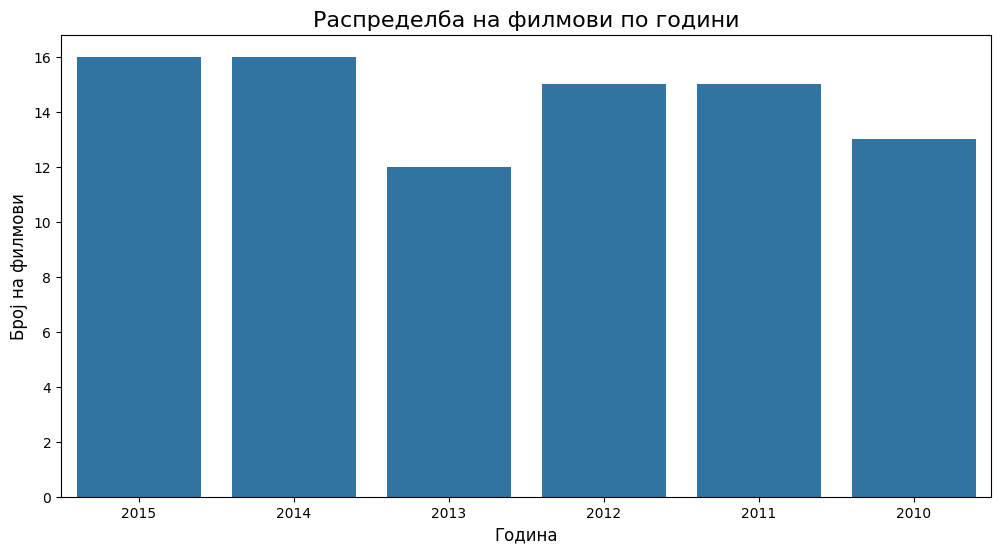

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Проверка дали DataFrame-от има податоци
if not df_movies.empty:
    # Сортирање на годините во опаѓачки редослед за подобра визуелизација
    year_order = sorted(df_movies['year'].unique(), reverse=True)
    
    plt.figure(figsize=(12, 6))
    
    # Користиме countplot за да го прикажеме бројот на филмови за секоја година
    sns.countplot(
        data=df_movies, 
        x='year', 
        order=year_order
    )
    
    plt.title('Распределба на филмови по години', fontsize=16)
    plt.xlabel('Година', fontsize=12)
    plt.ylabel('Број на филмови', fontsize=12)
    plt.show()
else:
    print("Нема податоци за визуелизација.")